In [607]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from acm import NominalACM
import matplotlib.pyplot as plt
from build_moex_curve import build_moex_curve
from ruonia import load_ruonia_1m, build_ruonia_monthly
from run_acm_model import run_acm_model
from sklearn.decomposition import PCA
from numpy.linalg import inv
from statsmodels.tools.tools import add_constant
from sparse_curve_interp import expand_sparse_zero_curve, expand_sparse_zero_curve_acm

In [608]:
# PARAMETRS
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / 'data' / 'dynamic.csv'
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_daily.csv'
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_monthly.csv'
RUONIA_1M_PATH = CLEAN_DIR / 'data' / 'ruonia_1M.csv'
START_DATE = "2003-01-04"
END_DATE = "2025-03-01"
N_FACTORS=5

In [609]:
def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )


def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    cols = tenor_columns(df)
    yield_curve = df[cols].copy()
    yield_curve.columns = [int(round(float(c[1:]) )) for c in cols]

    yield_curve = np.log1p(yield_curve / 100.0)
    yield_curve.columns.name = "maturity_months"
    return yield_curve

In [610]:
def get_short_rate(proxy):
    return np.log1p(proxy/100)/12

start_date = pd.to_datetime(START_DATE)
end_date = pd.to_datetime(END_DATE)
wide = pd.read_csv('data/full-yield-curve/yield_curve_wide.csv', parse_dates=['date'], index_col=['date']).loc[START_DATE:END_DATE]

dense_curve = expand_sparse_zero_curve(
    wide,
    months=range(1, 121),
    method="pchip"
)

dense_monthly = (
    dense_curve
    .set_index("date")
    .resample("ME")
    .mean()
    .reset_index()
)
yield_curve = expand_sparse_zero_curve_acm(
    dense_monthly,
    months=range(1, 121),
    method="pchip"
)
short_rate = yield_curve[1] / 12.0 

In [611]:
curve_m_cut = yield_curve.iloc[:, 2:]

mean_yields = curve_m_cut.mean()
curve_m_cut = curve_m_cut - mean_yields

pca = PCA(n_components=N_FACTORS)
pca.fit(curve_m_cut)
col_names = [f'PC {i + 1}' for i in range(N_FACTORS)]
df_loadings = pd.DataFrame(
    data=pca.components_.T,
    columns=col_names,
    index=curve_m_cut.columns,
)

df_pc_m = curve_m_cut @ df_loadings
sigma_factor = df_pc_m.std()
df_pc_m = df_pc_m / df_pc_m.std()
df_loadings = df_loadings / sigma_factor

# Enforce average positive loadings
sign_changes = np.sign(df_loadings.mean())
df_loadings = sign_changes * df_loadings
df_pc_m = sign_changes * df_pc_m

# Percent Explained
df_explained = pd.Series(
    data=pca.explained_variance_ratio_,
    name='Explained Variance',
    index=col_names,
)
df_explained

PC 1    0.970053
PC 2    0.026859
PC 3    0.002842
PC 4    0.000221
PC 5    0.000022
Name: Explained Variance, dtype: float64

<Axes: xlabel='maturity_months'>

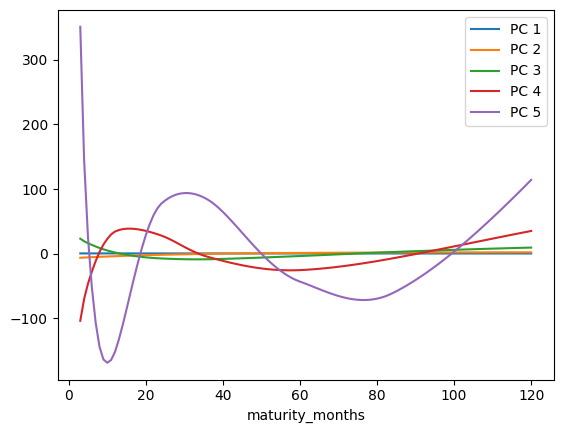

In [612]:
df_loadings.plot()

In [613]:
n = yield_curve.shape[1]
t_m = yield_curve.shape[0]
ttm = np.arange(1, n + 1) / 12
log_prices = - yield_curve * ttm
rf = short_rate.shift(1)
rx = (log_prices - log_prices.shift(1, axis=0).shift(-1, axis=1)).subtract(rf, axis=0)
rx = rx.shift(1, axis=1)

rx = rx.dropna(how='all', axis=0)
rx[1] = 0
rx

maturity_months,1,2,3,4,5,6,7,8,9,10,...,111,112,113,114,115,116,117,118,119,120
date,,,,,,,,,,,,,,,,,,,,,
2003-02-28,0,0.002098,0.004195,0.007067,0.009328,0.011547,0.013770,0.015938,0.017974,0.019959,...,0.184103,0.185677,0.187248,0.188817,0.190384,0.191948,0.193509,0.195067,0.196623,0.198176
2003-03-31,0,0.001036,0.002072,0.003936,0.005323,0.006710,0.008154,0.009599,0.010961,0.012316,...,0.120422,0.121546,0.122673,0.123803,0.124936,0.126072,0.127210,0.128352,0.129497,0.130644
2003-04-30,0,0.000460,0.000920,0.002111,0.002846,0.003587,0.004386,0.005195,0.005932,0.006660,...,0.052653,0.053083,0.053513,0.053945,0.054376,0.054809,0.055241,0.055674,0.056108,0.056541
2003-05-31,0,0.000630,0.001261,0.002587,0.003562,0.004557,0.005617,0.006703,0.007739,0.008773,...,0.080113,0.080654,0.081197,0.081743,0.082290,0.082841,0.083394,0.083949,0.084508,0.085070
2003-06-30,0,0.000665,0.001331,0.002567,0.003223,0.003809,0.004376,0.004867,0.005220,0.005521,...,0.032022,0.032315,0.032608,0.032899,0.033190,0.033480,0.033769,0.034057,0.034344,0.034630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31,0,-0.001072,-0.002145,-0.002924,-0.003849,-0.004767,-0.005659,-0.006553,-0.007493,-0.008427,...,-0.064871,-0.064814,-0.064756,-0.064697,-0.064638,-0.064578,-0.064518,-0.064460,-0.064402,-0.064346
2024-11-30,0,-0.001544,-0.003088,-0.004447,-0.005765,-0.007000,-0.008141,-0.009207,-0.010225,-0.011157,...,0.000984,0.001345,0.001707,0.002070,0.002433,0.002798,0.003163,0.003529,0.003896,0.004263
2024-12-31,0,0.000349,0.000699,0.001038,0.001414,0.001814,0.002248,0.002702,0.003157,0.003660,...,0.022430,0.022414,0.022400,0.022387,0.022377,0.022369,0.022363,0.022360,0.022361,0.022364


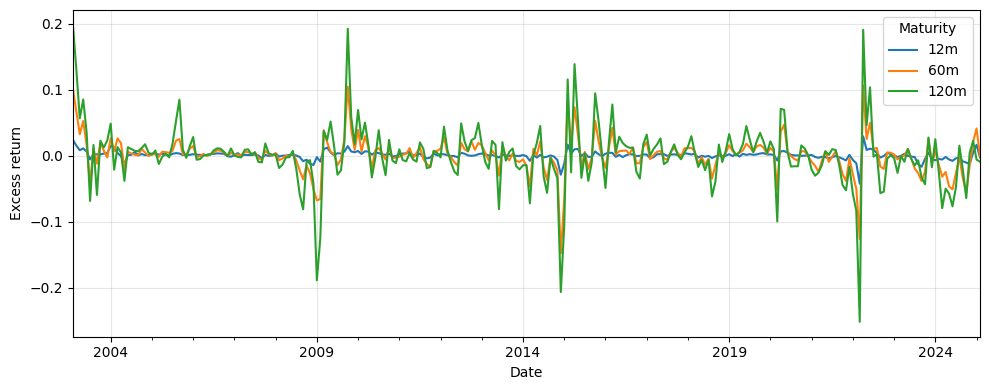

In [614]:
fig, ax = plt.subplots(figsize=(10, 4))

rx[12].plot(ax=ax, label="12m")
rx[60].plot(ax=ax, label="60m")
rx[120].plot(ax=ax, label="120m")

ax.set_xlabel("Date")
ax.set_ylabel("Excess return")
ax.legend(title="Maturity")
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [615]:
X = df_pc_m.T
X_lhs = X.values[:, 1:]  # X_t+1. Left hand side of VAR
X_rhs = np.vstack((np.ones((1, t_m-1)), X.values[:, 0:-1]))  # X_t and a constant.

var_coeffs = (X_lhs @ np.linalg.pinv(X_rhs))

phi = var_coeffs[:, 1:]

# Leave the estimated constant
# mu = var_coeffs[:, [0]]

# Force constant to zero
mu = np.zeros((N_FACTORS, 1))
var_coeffs[:, [0]] = 0

# Residuals
v = X_lhs - var_coeffs @ X_rhs
Sigma = v @ v.T / (t_m - 1)

s0 = np.cov(v).reshape((-1, 1))
var_coeffs[:,1:]

array([[ 0.9888076 , -0.01335474,  0.00828234,  0.01854697,  0.0016834 ],
       [-0.0153732 ,  0.93711601,  0.00181126, -0.01958883,  0.04161886],
       [ 0.02400971, -0.02324881,  0.86668304, -0.01385557, -0.05557252],
       [-0.02984403,  0.03385305,  0.04848941,  0.72752424,  0.09284449],
       [ 0.01237644, -0.05199051,  0.09352849, -0.00775944,  0.71249047]])

In [616]:
Z = np.vstack((np.ones((1, t_m-1)), X.values[:, :-1], v)).T  # Lagged X and Innovations
abc = inv(Z.T @ Z) @ (Z.T @ rx.values)
E = rx.values - Z @ abc
length = yield_curve.shape[1]
omega = np.var(E.reshape(-1, 1)) * np.eye(length)

abc = abc.T
beta = abc[:, -N_FACTORS:]

beta_star = np.zeros((length, N_FACTORS**2))

for i in range(length):
    beta_star[i, :] = np.kron(beta[i, :], beta[i, :]).T

In [617]:
factors = np.hstack([np.ones((t_m-1, 1)), df_pc_m.iloc[:-1].values])

# Orthogonalize factors with respect to v
v_proj = v.T @ np.linalg.pinv(v @ v.T) @ v
factors = factors - v_proj @ factors

adjustment = beta_star @ s0 + np.diag(omega).reshape(-1, 1)
rx_adjusted = rx.values + (1 / 2) * np.tile(adjustment, (1, t_m-1)).T
Y = (inv(factors.T @ factors) @ factors.T @ rx_adjusted).T

# Compute Lambda
X = beta
Lambda = inv(X.T @ X) @ X.T @ Y
lambda0 = Lambda[:, 0]
lambda1 = Lambda[:, 1:]

muStar = mu.reshape(-1) - lambda0
phiStar = phi - lambda1

lambda_table = pd.DataFrame(
    data = np.column_stack((lambda0.reshape(-1,1), lambda1)),
    columns = ["lambda0"] + [f"lambda1_{i+1}" for i in range(lambda1.shape[1])]
)
lambda_table.index = [f"Factor {i+1}" for i in range(lambda_table.shape[0])]

print("Lambdas (Market Prices of Risk):")
print(lambda_table)

Lambdas (Market Prices of Risk):
           lambda0  lambda1_1  lambda1_2  lambda1_3  lambda1_4  lambda1_5
Factor 1 -0.020016  -0.002726  -0.029865   0.015577   0.015573   0.002619
Factor 2  0.037951  -0.017617  -0.020200  -0.051923  -0.000976   0.034062
Factor 3 -0.009699   0.003360  -0.006715  -0.095106  -0.058860  -0.040178
Factor 4 -0.027838  -0.025276   0.006184   0.041571  -0.230460   0.026130
Factor 5  0.043499   0.022830  -0.014361   0.078699   0.108317  -0.229544


In [618]:
r1 = short_rate.reindex(df_pc_m.index)
X = add_constant(df_pc_m)
Delta = inv(X.T @ X) @ X.T @ r1
delta0 = Delta.iloc[0]
delta1 = Delta.iloc[1:].values
delta0, delta1

(np.float64(0.005694583823052605),
 array([ 2.42150690e-03, -9.13495128e-04,  3.55339144e-04, -1.23663895e-04,
         4.22293470e-05]))

In [619]:
def affine_coefficients( lambda0, lambda1):
        lambda0 = lambda0.reshape(-1, 1)
        n = yield_curve.shape[1]
        A = np.zeros(n)
        B = np.zeros((n, N_FACTORS))

        A[0] = - delta0
        B[0, :] = - delta1

        for n in range(1, n):
            Bpb = np.kron(B[n - 1, :], B[n - 1, :])
            s0term = 0.5 * (Bpb @ s0 + omega[0, 0])

            A[n] = (A[n - 1] + B[n - 1, :] @ (mu - lambda0) + s0term + A[0])[0]
            B[n, :] = B[n - 1, :] @ (phi - lambda1) + B[0, :]

        return A, B

In [620]:
# Affine Yield Coefficients
A, B = affine_coefficients(
            lambda0=lambda0,
            lambda1=lambda1,
        )

# Risk-Neutral Coefficients
Arn, Brn = affine_coefficients(
    lambda0=np.zeros(lambda0.shape),
    lambda1=np.zeros(lambda1.shape),
)


In [621]:
def compute_yields( A, B):
        A = A.reshape(-1, 1)
        multiplier = np.tile(yield_curve.columns / 12, (t_m, 1)).T
        yields = (- ((np.tile(A, (1,t_m)) + B @ df_pc_m.T) / multiplier).T).values
        yields = pd.DataFrame(
            data=yields,
            index=yield_curve.index,
            columns=yield_curve.columns,
        )
        return yields

In [622]:
# Model Implied Yield
miy = compute_yields(A, B)

# Risk Neutral Yield
rny = compute_yields(Arn, Brn)

tp = miy - rny

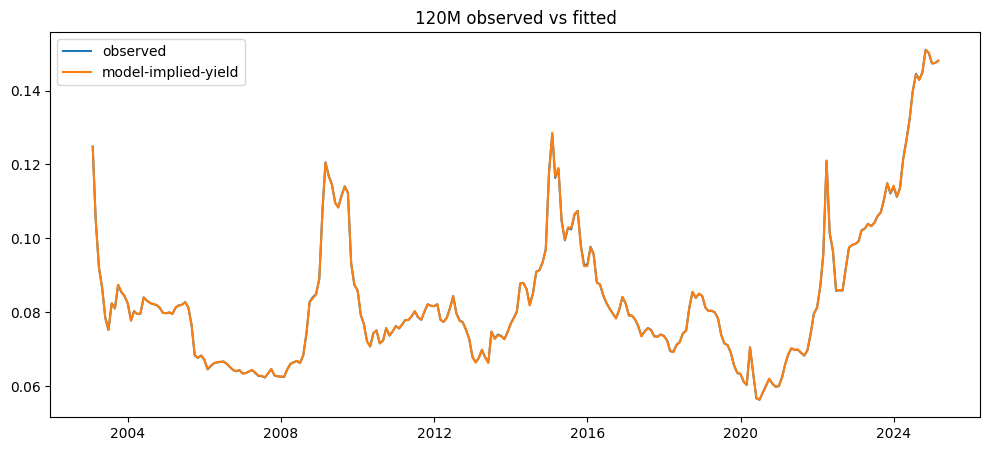

In [623]:
plt.figure(figsize=(12,5))
plt.title("120M observed vs fitted")
plt.plot(yield_curve[120], label='observed')
plt.plot(miy[120], label='model-implied-yield')
plt.legend()

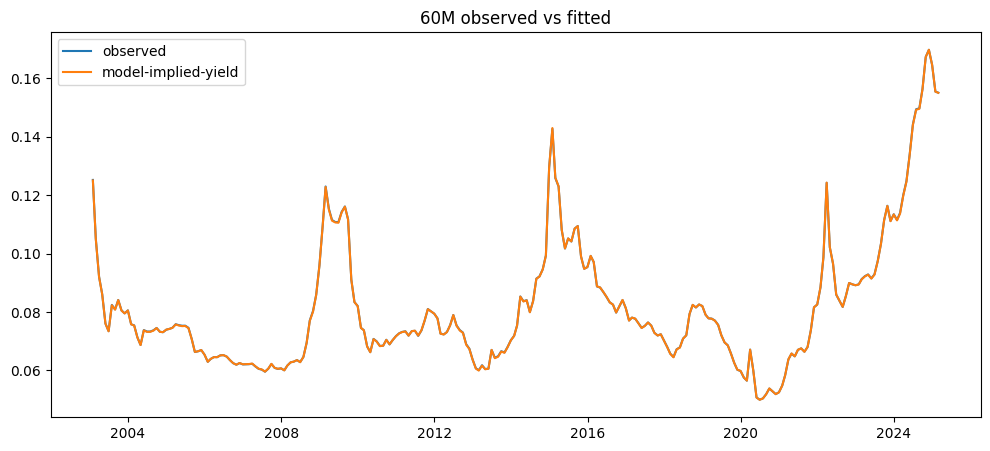

In [624]:
plt.figure(figsize=(12,5))
plt.title("60M observed vs fitted")
plt.plot(yield_curve[60], label='observed')
plt.plot(miy[60], label='model-implied-yield')
plt.legend()

In [625]:
TENORS = {
    "1Y": 12,
    "5Y": 60,
    "10Y": 120,
}
rows = {}

for label, tenor in TENORS.items():
    tmp = pd.concat(
        [
            yield_curve[tenor].rename("obs_log"),
            miy[tenor].rename("fit_log"),
        ],
        axis=1,
    ).dropna()

    obs_pct = np.expm1(tmp["obs_log"]) * 100
    fit_pct = np.expm1(tmp["fit_log"]) * 100
    err = fit_pct - obs_pct

    rows[label] = {
        "RMSE": np.sqrt(np.mean(err**2)),
        "MAE": np.mean(np.abs(err)),
        "Obs.": len(tmp),
    }

table_pca5 = pd.DataFrame(rows).loc[["RMSE", "MAE", "Obs."]]
print(f'PCA({N_FACTORS})')
table_pca5

PCA(5)


,1Y,5Y,10Y
RMSE,0.025372,0.008286,0.011247
MAE,0.018983,0.005897,0.007581
Obs.,266.000000,266.000000,266.000000


## Метрики апроксимации ЦБ
![качество апроксимации кривой доходности](cb_tp/inputs/error_cb.png)

np.float64(0.9615015176347443)

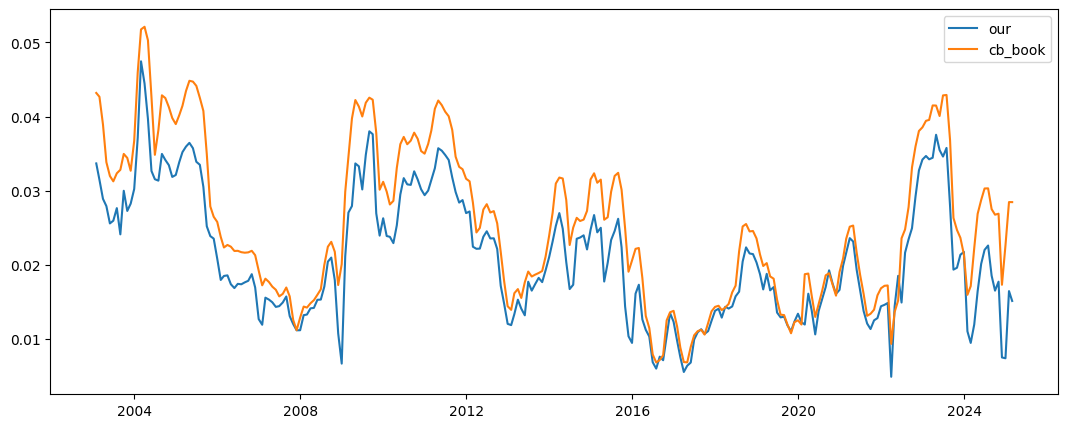

In [626]:
cb_tp_book = (
    pd.read_csv(Path("cb_tp/output/tp_10y_book_digitized_monthly.csv"), index_col=['date'],parse_dates=['date'])
    .rename(columns={"tp": "cb_tp_book"})
    ['cb_tp_book'].loc[START_DATE : END_DATE]
    )
cb_tp = (
    pd.read_csv(Path("cb_tp/output/cb_tp_digitized_monthly.csv"), parse_dates=["date"])
    .loc[lambda df: df["tenor_years"] == 10, ["date", "tp"]]
    .rename(columns={"tp": "cb_tp"})
    .set_index("date")
)

plt.figure(figsize=(13,5))
plt.plot(tp[120], label='our')
plt.plot(cb_tp_book/100, label='cb_book')
plt.legend()
cb_tp_book.corr(tp[120])